### Multi-Input Models

Character classification

### Two-input Dataset

In [4]:
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

In [5]:
from PIL import Image


class OmniglotDataset(Dataset):
    def __init__(self, transform, samples):
        self.transform = transform
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
       img_path, alphabet, label = self.samples[idx]
       image = Image.open(img_path).convert("L")
       image = self.transform(image)
       return image, alphabet, label 


Tensor concatenation

In [6]:
import torch.nn as nn
import torch
x = torch.tensor([
    [1, 2, 3],
])

y = torch.tensor([
    [4, 5, 6],
])

Concatenation along axis 0

In [7]:
torch.cat((x, y), dim=0)


tensor([[1, 2, 3],
        [4, 5, 6]])

Two-input architecture
- Define image processing layer
- Define alphabet processing layer
- Define classifier layer

In [9]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.image_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2),
            nn.ELU(),
            nn.Flatten(),
            nn.Linear(16 * 32 * 32, 128)
        )
        self.alphabet_layer = nn.Sequential(
           nn.Linear(30, 8),
           nn.ELU(), 
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 + 8, 964),
            )

### Two-input architecture
- Pass image through image layer
- Pass alphabet through alphabet layer
- Concatenate image and alphabet outputs

In [10]:
def forward(self, x_image, x_alphabet):
    x_image = self.image_layer(x_image)
    x_alphabet = self.alphabet_layer(x_alphabet)
    x = torch.cat((x_image, x_alphabet), dim=1)
    x = self.classifier(x)
    return x

### Training Loop
- Training data consists of three items:
    - image
    - Alphabet vector
    - Labels
- We pass the model images and alphabets

In [11]:
import torch.optim as optim

net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001)


for epoch in range(10):
    for img, alpha, labels in dataloader_train:
        optimizer.zero_grad()
        outputs = net(img, alpha)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()



NameError: name 'dataloader_train' is not defined

### Two-input dataset

In [ ]:
class OmniglotDataset(Dataset):
    def __init__(self, transform, samples):
		# Assign transform and samples to class attributes
        self.transform = transform
        self.samples = samples
                    
    def __len__(self):
		# Return number of samples
        return len(self.samples)

    def __getitem__(self, idx):
      	# Unpack the sample at index idx
        img_path, alphabet, label = self.samples[idx]
        img = Image.open(img_path).convert('L')
        # Transform the image 
        img_transformed = self.transform(img)
        return img_transformed, alphabet, label

In [ ]:
dataset_train = OmniglotDataset(
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((64, 64)),
    ]),
    samples=samples,
)

dataloader_train = DataLoader(
    dataset_train, shuffle=True, batch_size=3,
)

### Two-input model

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # Define sub-networks as sequential models
        self.image_layer = nn.Sequntial(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2),
            nn.ELU(),
            nn.Flatten(),
            nn.Linear(16*32*32, 128)
        )
        self.alphabet_layer = nn.Sequntial(
            nn.Linear(30, 8),
            nn.ELU(), 
        )
        self.classifier = nn.Sequntial(
            nn.Linear(128 + 8, 964), 
        )

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # Define sub-networks as sequential models
        self.image_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2),
            nn.ELU(),
            nn.Flatten(),
            nn.Linear(16*32*32, 128)
        )
        self.alphabet_layer = nn.Sequential(
            nn.Linear(30, 8),
            nn.ELU(), 
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 + 8, 964), 
        )
        
    def forward(self, x_image, x_alphabet):
		# Pass the x_image and x_alphabet through appropriate layers
        x_image = self.image_layer(x_image)
        x_alphabet = self.alphabet_layer(x_alphabet)
        # Concatenate x_image and x_alphabet
        x = torch.cat((x_image, x_alphabet), dim=1)
        return self.classifier(x)

Training two-input model

In [ ]:
for img, alpha, labels in dataloader_train: outputs = net(img, alpha)

### Multi-output models

Two-output Dataset

In [ ]:
class OmiglotDataset(Dataset):
    def __init__(self, transform, samples):
        self.transform = transform
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
       img_path, alphabet, label = self.samples[idx]
       img = Image.open(img_path).convert("L")
       img = self.transform(img)
       return img, alphabet, label

### Two-output architecture
- Define image-processing sub-network
- Define output-specific classifiers
- Pass image through dedicated sub-network
- Pass the result through each output layer
- Return both outputs

In [ ]:
class Net(nn.Module):
    def __init__(self, num_alpha, num_char):
        super().__init__()
        self.image_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2),
            nn.ELU(),
            nn.Flatten(),
            nn.Linear(16*32*32, 128)
        )
        self.classifier_alpha = nn.Linear(128, 30)
        self.classifier_char = nn.Linear(128, 964)

    def forward(self, x):
        x_image = self.image_layer(x)
        output_alpha = self.classifier_alpha(x_image)
        output_char = self.classifier_char(x_image)
        return output_alpha, output_char

### Training Loop
- Model produces two outputs
- Calculate loss for each output
- Combine the losses to one total loss
- Backprop and optimize with the total loss


In [ ]:
for epoch in range(10):
    for images, labels_alpha, labels_char in dataloader_train:
        optimizer.zero_grad()
        output_alpha, output_char = net(images)
        loss_alpha = criterion(output_alpha, labels_alpha)
        loss_char = criterion(output_char, labels_char)
        loss = loss_alpha + loss_char
        loss.backward()
        optimizer.step()

In [ ]:
# Print the sample at index 100
print(samples[100])

# Create dataset_train
dataset_train = OmniglotDataset(
    transform=transforms.Compose([
        transforms.ToTensor(),
      	transforms.Resize((64, 64)),
    ]),
    samples=samples,
)

# Create dataloader_train
dataloader_train = DataLoader(
    dataset_train, shuffle=True, batch_size=3,
)

### Two-output model architecture

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.image_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2),
            nn.ELU(),
            nn.Flatten(),
            nn.Linear(16*32*32, 128)
        )
        # Define the two classifier layers
        self.classifier_alpha = nn.Linear(128, 30)
        self.classifier_char = nn.Linear(128, 964)
        
    def forward(self, x):
        x_image = self.image_layer(x)
        # Pass x_image through the classifiers and return both results
        output_alpha = self.classifier_alpha(x_image)
        output_char = self.classifier_char(x_image)
        return output_alpha, output_char

Training multi-output models

In [ ]:
net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.05)

for epoch in range(1):
    for images, labels_alpha, labels_char in dataloader_train:
        optimizer.zero_grad()
        outputs_alpha, outputs_char = net(images)
        # Compute alphabet classification loss
        loss_alpha = criterion(outputs_alpha, labels_alpha)
        # Compute character classification loss
        loss_char = criterion(outputs_char, labels_char)
        # Compute total loss
        loss = loss_alpha + loss_char
        loss.backward()
        optimizer.step()

### Evaluation of multi-output models and loss weighting

Model evaluation
- Set up metric for each output
- Iterate over test loader and get outputs
- Calculate prediction for each output
- Update accuracy scores

In [ ]:
acc_alpha = Accuracy(
    task="multiclass", num_classes=30
)
acc_char = Accuracy(
    task="multiclass", num_classes=964
)

net.eval()
with torch.no_grad():
    for images, labels_alpha, labels_char in dataloader_test:
        outputs_alpha, outputs_char = net(images)
        _, preds_alpha = torch.max(outputs_alpha, 1)
        _, preds_char = torch.max(outputs_char, 1)
        acc_alpha.update(preds_alpha, labels_alpha)
        acc_char.update(preds_char, labels_char)

print(f"Alphabet classification accuracy: {acc_alpha.compute()}")
print(f"Character classification accuracy: {acc_char.compute()}")

Multi-output training loop revisited
- Two losses: for alphabets and characters
- Final loss defined as sum alphabet and character losses:
`loss = loss_alpha + loss_char`
- Both classification tasks deemed equally important

In [ ]:
for epoch in range(10):
    for images, labels_alpha, labels_char in dataloader_train:
        optimizer.zero_grad()
        output_alpha, output_char = net(images)
        loss_alpha = criterion(output_alpha, labels_alpha)
        loss_char = criterion(output_char, labels_char)
        loss = loss_alpha + loss_char
        loss.backward()
        optimizer.step()

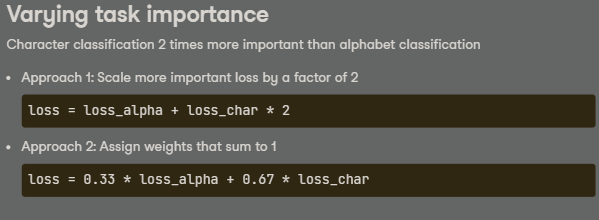

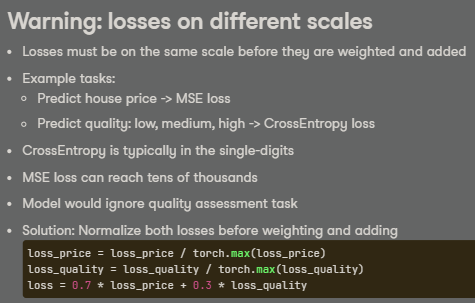

Multi-output model evaluation

In [ ]:
def evaluate_model(model):
    # Define accuracy metrics
    acc_alpha = Accuracy(task="multiclass", num_classes=30)
    acc_char = Accuracy(task="multiclass", num_classes=964)

    model.eval()
    with torch.no_grad():
        for images, labels_alpha, labels_char in dataloader_test:
            # Obtain model outputs
            outputs_alpha, outputs_char = model(images)
            _, pred_alpha = torch.max(outputs_alpha, 1)
            _, pred_char = torch.max(outputs_char, 1)
			# Update both accuracy metrics
            acc_alpha(pred_alpha, labels_alpha)
            acc_char(pred_char, labels_char)
    
    print(f"Alphabet: {acc_alpha.compute()}")
    print(f"Character: {acc_char.compute()}")